# Forward-knee refinement with convergence patience 50

This run matches the fixed-stratified five-member forward-knee refinement with
joint all-model proposals and a 500-step maximum, but stops after 50
consecutive proposals fail to improve the ensemble-validation objective.

In [1]:
from pathlib import Path
import copy
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "mistic" / "svmSet.py").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svc, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

Matplotlib is building the font cache; this may take a moment.


## Fixed experimental design

- 500 observations and 100 predictors: 10 informative, 10 redundant, and 80 noise.
- One stratified 25% blind set, withheld before every preprocessing and modeling step.
- Three inner seeds and exactly five SVM-set members.
- Fifteen percent of the outer-training rows are reserved for ensemble-level validation and excluded from all member CV splits.
- `combined_rank(weight=0.75)`, separate feature sets, and separate parameters.
- Forward search uses the 20-medoid singleton screen and a 20-feature maximum.
- Backward search uses scaled gamma during search and final full-grid retuning.
- Greedy selection returns the knee-selected subset before refinement.
- Stochastic variants start from identical deep copies of that subset. Every iteration budget uses the same seed. Both single-model proposals and joint all-model proposals are tested.
- Each sklearn unified-feature reference uses only the top `knee_feature_count`
  features according to the corresponding ensemble's unified rank.

In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))

X_values, y_values = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    n_redundant=N_REDUNDANT,
    n_repeated=0,
    n_classes=2,
    weights=[0.55, 0.45],
    class_sep=1.0,
    flip_y=0.03,
    shuffle=False,
    random_state=2026,
)
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="class")

MODEL_COUNTS = [5]
REFINEMENT_STEPS = [0, 10, 20, 50, 100]
SELECTION_STRATEGIES = ["forward_knee", "backward_knee"]
INNER_SEEDS = list(range(3))
BLIND_SET_SEED = 42
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
ENSEMBLE_VALIDATION_SIZE = 0.15
RANK_WEIGHT = 0.75
FORWARD_MAX_FEATURES = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]

X_train, X_blind, y_train, y_blind = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=BLIND_SET_SEED
)
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")

Training rows: 375; fixed blind rows: 125


In [3]:
def parameter_grid():
    return [
        paramSet(model={"C": cost}, kernel={"gamma": gamma})
        for cost in C_VALUES for gamma in GAMMA_VALUES
    ]


def metric_row(y_true, predictions, decision_values):
    return {
        "roc_auc": roc_auc_score(y_true, decision_values),
        "f1": f1_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "accuracy": accuracy_score(y_true, predictions),
    }


def fit_sklearn_reference(X_train_subset, y_train, seed):
    pipeline = Pipeline([
        ("scale", StandardScaler()),
        ("svc", SVC(kernel="rbf", class_weight="balanced")),
    ])
    search = GridSearchCV(
        pipeline,
        {"svc__C": C_VALUES, "svc__gamma": GAMMA_VALUES},
        scoring="roc_auc",
        cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1,
        refit=True,
    )
    return search.fit(X_train_subset, y_train)


def fit_knee_ensemble(strategy, num_models, seed):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(
        X_scaled,
        np.asarray(y_train),
        num_feature_medoids=20,
        ensemble_validation_size=ENSEMBLE_VALIDATION_SIZE,
        ensemble_validation_random_seed=50_000,
        ensemble_validation_stratify=True,
    )
    splits.classification(
        num_sets=num_models,
        validation_size=INNER_VALIDATION_SIZE,
        random_seed=seed,
    )
    ensemble = svmSet(
        SVC(kernel="precomputed", class_weight="balanced"),
        splits,
        score_method=score_svc(weight=1.0).score,
        kernel=kernelWrapper(type="rbf"),
        separate_feature_sets=True,
        separate_parameters=True,
    )
    options = dict(
        parameter_grid=parameter_grid(),
        feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
        set_for_rank="sample",
        tune_models_each_step=False,
        post_find_knee=True,
    )
    if strategy == "forward_knee":
        ensemble.greedy_forward_selection(
            reduction_factor=0,
            max_features=FORWARD_MAX_FEATURES,
            **options,
        )
    else:
        ensemble.greedy_backward_selection(reduction_factor=0.1, **options)
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified_set = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([
        feature for feature in ensemble.unified_sorted_features
        if feature in unified_set
    ], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), 1 - signal_count / len(features)


def ensemble_row(ensemble, scaler, seed, strategy, num_models, steps, knee_count, update_all_models):
    X_blind_scaled = scaler.transform(X_blind)
    predictions = ensemble.predict(X_blind_scaled)
    decisions = ensemble.decision_function(X_blind_scaled)
    unified = np.asarray(ensemble.unified_features, dtype=int)
    top20 = ranked_unified_features(ensemble, 20)
    signal_recall, noise_fraction = recovery(top20)
    member_predictions = np.column_stack([
        ensemble.predict(X_blind_scaled, model_index=i) for i in range(num_models)
    ])
    disagreement = np.mean([
        np.mean(member_predictions[:, i] != member_predictions[:, j])
        for i in range(num_models) for j in range(i + 1, num_models)
    ]) if num_models > 1 else 0.0
    history = getattr(ensemble, "stochastic_performance_", [])
    return {
        "seed": seed,
        "method": "MiSTIC SVM set",
        "selection_strategy": strategy,
        "refinement_steps": steps,
        "update_all_models": update_all_models,
        "refinement_objective": "ensemble_validation" if steps else "knee_baseline",
        "num_models": num_models,
        "knee_feature_count": knee_count,
        "num_unified_features": len(unified),
        "signal_recall": signal_recall,
        "noise_fraction": noise_fraction,
        "member_disagreement": disagreement,
        "accepted_moves": sum(row.accepted for row in history),
        **metric_row(y_blind, predictions, decisions),
    }


def reference_row(ensemble, seed, strategy, num_models, steps, knee_count, update_all_models):
    features = ranked_unified_features(ensemble, knee_count)
    signal_recall, noise_fraction = recovery(features)
    reference = fit_sklearn_reference(X_train.iloc[:, features], y_train, seed)
    return {
        "seed": seed,
        "method": "sklearn on knee-ranked unified features",
        "selection_strategy": strategy,
        "refinement_steps": steps,
        "update_all_models": update_all_models,
        "refinement_objective": "ensemble_validation" if steps else "knee_baseline",
        "num_models": num_models,
        "knee_feature_count": knee_count,
        "num_unified_features": len(features),
        "signal_recall": signal_recall,
        "noise_fraction": noise_fraction,
        "member_disagreement": 0.0,
        "accepted_moves": np.nan,
        **metric_row(
            y_blind,
            reference.predict(X_blind.iloc[:, features]),
            reference.decision_function(X_blind.iloc[:, features]),
        ),
    }

## Run the comparison

For each seed and selection direction, the two refined conditions begin from
independent copies of the same knee-selected ensemble. Refinement retunes every
proposal with the same parameter grid used by the greedy search.

In [4]:
rows = []
strategy = "forward_knee"
num_models = 5
steps = 500
update_all_models = True

for seed in INNER_SEEDS:
    scaler, base_ensemble, knee_count = fit_knee_ensemble(
        strategy, num_models, seed
    )
    candidate = copy.deepcopy(base_ensemble)
    candidate.stochastic_feature_selection(
        parameter_grid(),
        n_iterations=steps,
        feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
        set_for_rank="sample",
        temperature=0.05,
        cooling_rate=0.97,
        add_probability=0.5,
        random_seed=10_000 + 100 * num_models + seed,
        update_all_models=True,
        use_ensemble_validation=True,
        convergence_patience=50,
    )
    rows.append(ensemble_row(
        candidate, scaler, seed, strategy, num_models, steps,
        knee_count, update_all_models,
    ))
    rows.append(reference_row(
        candidate, seed, strategy, num_models, steps,
        knee_count, update_all_models,
    ))
    for row in rows[-2:]:
        row["iterations_run"] = candidate.stochastic_iterations_
        row["converged"] = candidate.stochastic_converged_
        row["stop_reason"] = candidate.stochastic_stop_reason_
    print(f"completed seed={seed}, forward_knee, models=5, steps=200, update_all_models=True")

results_200 = pd.DataFrame(rows)
results_200.to_csv(
    repo_root / "validation/Synthetic100_svmSet_forward_500_patience50_fixed_stratified_results.csv",
    index=False,
)
results_200

Number of Features: 1, Score: 0.648


Number of Features: 2, Score: 0.667


Number of Features: 3, Score: 0.682


Number of Features: 4, Score: 0.697


Number of Features: 5, Score: 0.684


...

Number of Features: 18, Score: 0.760


Number of Features: 19, Score: 0.756


Number of Features: 20, Score: 0.759
Number of Features: 100, Score: 0.750


completed seed=2, forward_knee, models=5, steps=200, update_all_models=True


,seed,method,selection_strategy,refinement_steps,update_all_models,refinement_objective,num_models,knee_feature_count,num_unified_features,signal_recall,noise_fraction,member_disagreement,accepted_moves,roc_auc,f1,balanced_accuracy,accuracy,iterations_run,converged,stop_reason
0,0,MiSTIC SVM set,forward_knee,500,True,ensemble_validation,5,19,53,0.70,0.300000,0.2416,80.0,0.906056,0.796610,0.810947,0.808,107,True,converged
1,0,sklearn on knee-ranked unified features,forward_knee,500,True,ensemble_validation,5,19,19,0.70,0.263158,0.0000,NaN,0.952122,0.904348,0.913561,0.912,107,True,converged
2,1,MiSTIC SVM set,forward_knee,500,True,ensemble_validation,5,12,36,0.70,0.300000,0.1856,55.0,0.936077,0.854545,0.868918,0.872,63,True,converged
3,1,sklearn on knee-ranked unified features,forward_knee,500,True,ensemble_validation,5,12,12,0.50,0.166667,0.0000,NaN,0.965321,0.894737,0.904633,0.904,63,True,converged
4,2,MiSTIC SVM set,forward_knee,500,True,ensemble_validation,5,17,65,0.55,0.450000,0.2512,69.0,0.892340,0.810345,0.825440,0.824,180,True,converged
5,2,sklearn on knee-ranked unified features,forward_knee,500,True,ensemble_validation,5,17,17,0.50,0.411765,0.0000,NaN,0.944617,0.800000,0.824275,0.832,180,True,converged


## Patience-50 comparison

Rows are paired with the unrestricted 200-step run and the matching
fixed-stratified zero-step baseline.

In [5]:
patience50 = results_200.query("method == 'MiSTIC SVM set'")
unrestricted = pd.read_csv(
    repo_root / "validation/Synthetic100_svmSet_forward_200_fixed_stratified_validation_results.csv"
).query("method == 'MiSTIC SVM set'")
baseline = pd.read_csv(
    repo_root / "validation/Synthetic100_svmSet_forward_fixed_stratified_baseline_results.csv"
).query("method == 'MiSTIC SVM set'")

comparison_rows = pd.concat([
    baseline.assign(condition="zero-step baseline"),
    patience50.assign(condition="patience 50"),
    unrestricted.assign(condition="unrestricted 200"),
], ignore_index=True)
comparison_rows.groupby("condition").agg(
    mean_auc=("roc_auc", "mean"),
    sd_auc=("roc_auc", "std"),
    mean_f1=("f1", "mean"),
    mean_accuracy=("accuracy", "mean"),
    mean_signal_recall=("signal_recall", "mean"),
    mean_union_size=("num_unified_features", "mean"),
    mean_iterations_run=("iterations_run", "mean"),
).round(4)

,mean_auc,sd_auc,mean_f1,mean_accuracy,mean_signal_recall,mean_union_size,mean_iterations_run
condition,,,,,,,
patience 50,0.9115,0.0224,0.8205,0.8347,0.6500,51.3333,116.6667
unrestricted 200,0.9099,0.0123,0.8078,0.8267,0.6333,53.6667,NaN
zero-step baseline,0.9249,0.0341,0.8293,0.8427,0.6500,38.3333,NaN


In [6]:
old = unrestricted.set_index("seed")
new = patience50.set_index("seed")
paired = pd.DataFrame({
    "delta_auc_patience50_minus_unrestricted": new["roc_auc"] - old["roc_auc"],
    "delta_f1_patience50_minus_unrestricted": new["f1"] - old["f1"],
    "delta_recall_patience50_minus_unrestricted": new["signal_recall"] - old["signal_recall"],
    "delta_union_patience50_minus_unrestricted": new["num_unified_features"] - old["num_unified_features"],
    "iterations_run": new["iterations_run"],
    "stop_reason": new["stop_reason"],
})
pd.concat([paired, pd.DataFrame([paired.select_dtypes("number").mean().rename("mean")])])

,delta_auc_patience50_minus_unrestricted,delta_f1_patience50_minus_unrestricted,delta_recall_patience50_minus_unrestricted,delta_union_patience50_minus_unrestricted,iterations_run,stop_reason
0,-0.002070,-0.013307,0.000000,-1.000000,107.000000,converged
1,0.013199,0.058429,0.050000,-8.000000,63.000000,converged
2,-0.006211,-0.007046,0.000000,2.000000,180.000000,converged
mean,0.001639,0.012692,0.016667,-2.333333,116.666667,NaN


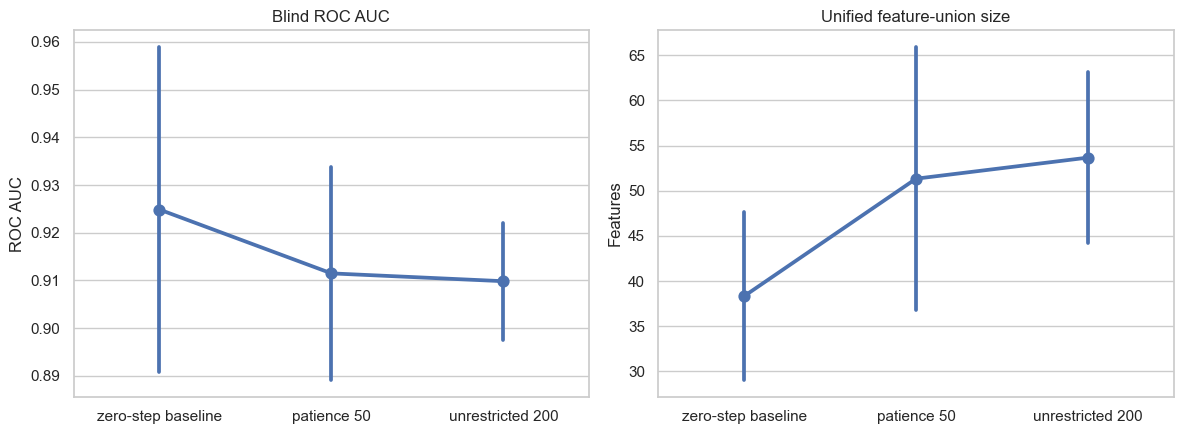

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.pointplot(data=comparison_rows, x="condition", y="roc_auc", errorbar="sd", ax=axes[0])
axes[0].set(title="Blind ROC AUC", xlabel="", ylabel="ROC AUC")
sns.pointplot(data=comparison_rows, x="condition", y="num_unified_features", errorbar="sd", ax=axes[1])
axes[1].set(title="Unified feature-union size", xlabel="", ylabel="Features")
plt.tight_layout()